In [1]:
!pip install torch torchvision torchaudio tqdm

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

print("Path to dataset files:", path)

100%|██████████| 329M/329M [00:21<00:00, 16.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
from pathlib import Path
import json
from datetime import datetime
from torch.utils.data import random_split

In [46]:
import os
for dir,root,s in os.walk(path):
  break
print(dir)
print(root,len(root))

/root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1
['PlantVillage'] 1 []


In [48]:
CLASS_LABELS =  [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two-spotted_spider_mite",
    "Tomato_Target_Spot",
    "Tomato_Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_Tomato_mosaic_virus",
    "Tomato_healthy"
]

In [62]:
# Configurable: dataset paths, sizes (modify these)
DATASET_PATH = f'{path}/PlantVillage'  # Your dataset folder (train/val/test subdirs)
BATCH_SIZE = 32  # Modify as needed
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
IMG_SIZE = 224  # Fixed to 224 as requested
NUM_CLASSES = 15  # From your notebook
TRAIN_SPLIT = 0.8  # 80% train
VAL_SPLIT = 0.2    # 20% val
TEST_SIZE = None   # Full test set
# Training callbacks
PATIENCE = 10  # Early stopping patience
CHECKPOINT_EVERY = 5  # Save checkpoint every N epochs
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

In [63]:
# Transforms: resize to 224, normalize (ImageNet stats), augment train
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [65]:
from torch.utils.data import random_split
# Load full dataset
full_dataset = ImageFolder(DATASET_PATH, transform=train_transform)  # Use train_transform initially
print(f"Full dataset: {len(full_dataset)} samples")
print(f"Classes: {full_dataset.classes}")


Full dataset: 20638 samples
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [66]:
# Split into train/val
train_size = int(TRAIN_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_test_transform

In [67]:
if TEST_SIZE is None:
    test_dataset = val_dataset
else:
    test_dataset, _ = random_split(val_dataset, [TEST_SIZE, len(val_dataset) - TEST_SIZE])

In [68]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)},batch size :{BATCH_SIZE}")

Train: 16510, Val: 4128, Test: 4128,batch size :32


In [69]:
class PlantCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv5 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv6 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv7 = nn.Conv2d(64, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # 224x224x3
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.pool(F.relu(self.conv5(x)))
        x = F.relu(self.conv6(x))
        x = self.pool(F.relu(self.conv7(x)))
        x = x.view(-1, 64 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PlantCNN().to(device)
print(model)
print(f"Using device: {device}")

PlantCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=15, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Using device: cuda


In [71]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

class EarlyStopping:
    def __init__(self, patience=PATIENCE, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

early_stopping = EarlyStopping()

In [72]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
BATCH_SIZE = 32
PATIENCE = 10
CHECKPOINT_EVERY = 5

In [73]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # === TRAIN ===
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    train_progress = tqdm(train_loader, desc='Training')

    for inputs, labels in train_progress:
        batch_size = min(inputs.size(0), labels.size(0), BATCH_SIZE)
        inputs, labels = inputs[:batch_size].to(device), labels[:batch_size].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(f"labels:{len(labels)},inputs :{len(inputs)},outputs:{len(outputs)}") debug
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_size
        _, predicted = outputs.max(1)
        total += batch_size
        correct += predicted.eq(labels).sum().item()

        train_progress.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.1f}%'
        })

    train_loss = total_loss / total
    train_acc = 100. * correct / total

    # === VALIDATE ===
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    val_progress = tqdm(val_loader, desc='Validation')

    with torch.no_grad():
        for inputs, labels in val_progress:
            batch_size = min(inputs.size(0), labels.size(0), BATCH_SIZE)
            inputs, labels = inputs[:batch_size].to(device), labels[:batch_size].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * batch_size
            _, predicted = outputs.max(1)
            total += batch_size
            correct += predicted.eq(labels).sum().item()

            val_progress.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.1f}%'
            })

    val_loss = total_loss / total
    val_acc = 100. * correct / total

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}% | Val: Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Scheduler
    scheduler.step(val_loss)

    # CHECKPOINT every N epochs
    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        checkpoint = {
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history
        }
        torch.save(checkpoint, f'models/checkpoint_epoch_{epoch+1}.pth')
        print(f"Checkpoint saved: checkpoint_epoch_{epoch+1}.pth")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'models/best_model.pth')
        print("New best model saved!")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("model saved")



Epoch 1/50


Training:   0%|          | 0/516 [00:00<?, ?it/s]

Validation:   0%|          | 0/129 [00:00<?, ?it/s]

Train: Loss=2.2773, Acc=23.22% | Val: Loss=1.8116, Acc=41.67%
LR: 0.001000
New best model saved!

Epoch 2/50


Training:   0%|          | 0/516 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/129 [00:00<?, ?it/s]

Train: Loss=0.0097, Acc=99.69% | Val: Loss=0.1823, Acc=97.04%
LR: 0.000250
Patience: 9/10

Epoch 40/50


Training:   0%|          | 0/516 [00:00<?, ?it/s]

Validation:   0%|          | 0/129 [00:00<?, ?it/s]

Train: Loss=0.0066, Acc=99.79% | Val: Loss=0.1799, Acc=97.34%
LR: 0.000250
Checkpoint saved: checkpoint_epoch_40.pth
Patience: 10/10
Early stopping at epoch 40
model saved


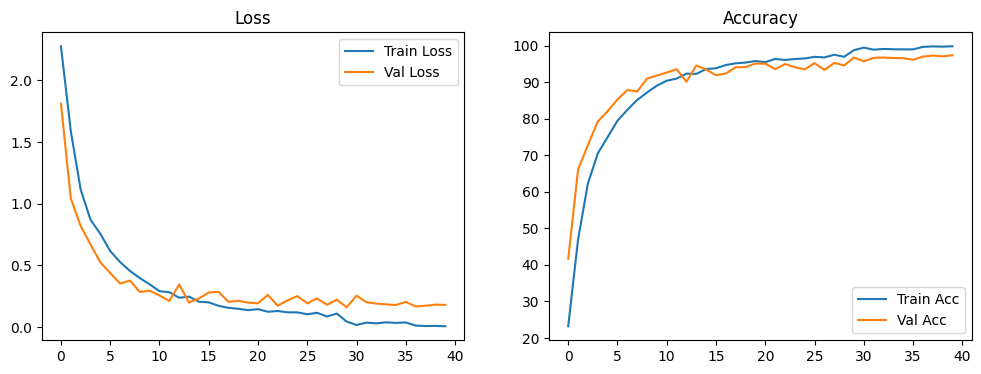

In [74]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [75]:
test_loss, test_acc = val_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Val:   0%|          | 0/129 [00:00<?, ?it/s]

Test Loss: 0.1799, Test Acc: 97.34%
